In [48]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


# Cleaning Data
#### วิธีทำ
1. Load data
2. Data Reshaping (Pivot Table)
3.  Return Transformation (Daily Log Returns)
4.  Handling Missing Values (ตัดหุ้นที่มีค่าว่างออก)
5.  Standardization & Transpose (ปรับสเกลและสลับมิติให้หุ้นเป็น Samples พร้อมเข้าโมเดล)

In [4]:
# step 1
df = pd.read_csv('NASDAQ-100/NASDAQ_100_Data_From_2010.csv', sep='\t')
df['Date'] = pd.to_datetime(df['Date'])

# step 2
price_matrix = df.pivot(index='Date', columns='Name', values='Adj Close')

#step 3 
returns_matrix = np.log(price_matrix / price_matrix.shift(1)).iloc[1:]

# step 4 
clean_returns = returns_matrix.dropna(axis=1)

# step 5 
scaler = StandardScaler()
X = scaler.fit_transform(clean_returns).T
# X = scaler.fit_transform(clean_returns)
stock_names = clean_returns.columns.tolist()
print(stock_names)

['AAPL', 'ADBE', 'ADI', 'ADP', 'ADSK', 'AEP', 'ALGN', 'AMAT', 'AMD', 'AMGN', 'AMZN', 'ANSS', 'ASML', 'ATVI', 'AVGO', 'BIDU', 'BIIB', 'BKNG', 'CDNS', 'CERN', 'CHKP', 'CMCSA', 'COST', 'CPRT', 'CSCO', 'CSX', 'CTAS', 'CTSH', 'DLTR', 'DXCM', 'EA', 'EBAY', 'EXC', 'FAST', 'FISV', 'GILD', 'GOOG', 'GOOGL', 'HON', 'IDXX', 'ILMN', 'INCY', 'INTC', 'INTU', 'ISRG', 'KDP', 'KLAC', 'LRCX', 'LULU', 'MAR', 'MCHP', 'MDLZ', 'MELI', 'MNST', 'MRVL', 'MSFT', 'MTCH', 'MU', 'NFLX', 'NTES', 'NVDA', 'ORLY', 'PAYX', 'PCAR', 'PEP', 'QCOM', 'REGN', 'ROST', 'SBUX', 'SGEN', 'SIRI', 'SNPS', 'SWKS', 'TCOM', 'TMUS', 'TXN', 'VRSK', 'VRSN', 'VRTX', 'WBA', 'XEL', 'XLNX']


## PCA

In [49]:
from sklearn.decomposition import PCA

In [50]:
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(X)
print(pca_features)

[[  6.21834189  -1.27885912]
 [  5.9434352    1.83379021]
 [ 16.29613274 -13.18185038]
 [-10.33934962 -12.69074945]
 [  9.74565599  -0.65139311]
 [-32.15792995  -7.91346963]
 [  1.18159472   2.85965577]
 [ 17.65546345 -13.26025142]
 [ 12.24570031   3.42651587]
 [-10.38357362  12.33433029]
 [  6.12055259  12.37406335]
 [  5.70262691  -3.59325814]
 [ 14.33509715  -7.51023555]
 [  5.1365111   10.63130986]
 [ 14.1265801   -6.21604536]
 [ 11.45258893  10.04343904]
 [ -5.79257467  21.73976191]
 [  2.22390076   1.18475658]
 [  9.48888779  -4.54757249]
 [ -7.26915528   5.2722839 ]
 [  0.55077764   2.27919298]
 [ -9.43240146  -5.30597598]
 [-13.40700997  -1.15573596]
 [ -4.67479093  -5.12469263]
 [ -0.31587272  -6.8751843 ]
 [ -3.46006489  -9.13343176]
 [ -7.08404342 -11.62009502]
 [ -2.61608559  -6.94295099]
 [-11.6402396    2.54494749]
 [ -1.96377867  16.0984867 ]
 [  4.50759002   9.47485627]
 [  3.31557082   6.76075463]
 [-25.4454509  -13.36105298]
 [ -4.71854583  -3.61502292]
 [ -7.898212  

## Hierarchical Clustering
### วิธีการทำ
1. คำนวณ Hierarchical Clustering
   - คำนวณ Correlation Matrix ของหุ้น
   - แปลง Correlation เป็น Distance Matrix
3. วาดรูป Dendrogram
4. ตัด Cluster ออกมาใช้งาน
5. สร้าง DataFrame สรุปว่าหุ้นไหนอยู่กลุ่มไหน

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.preprocessing import StandardScaler
import scipy.spatial.distance as ssd

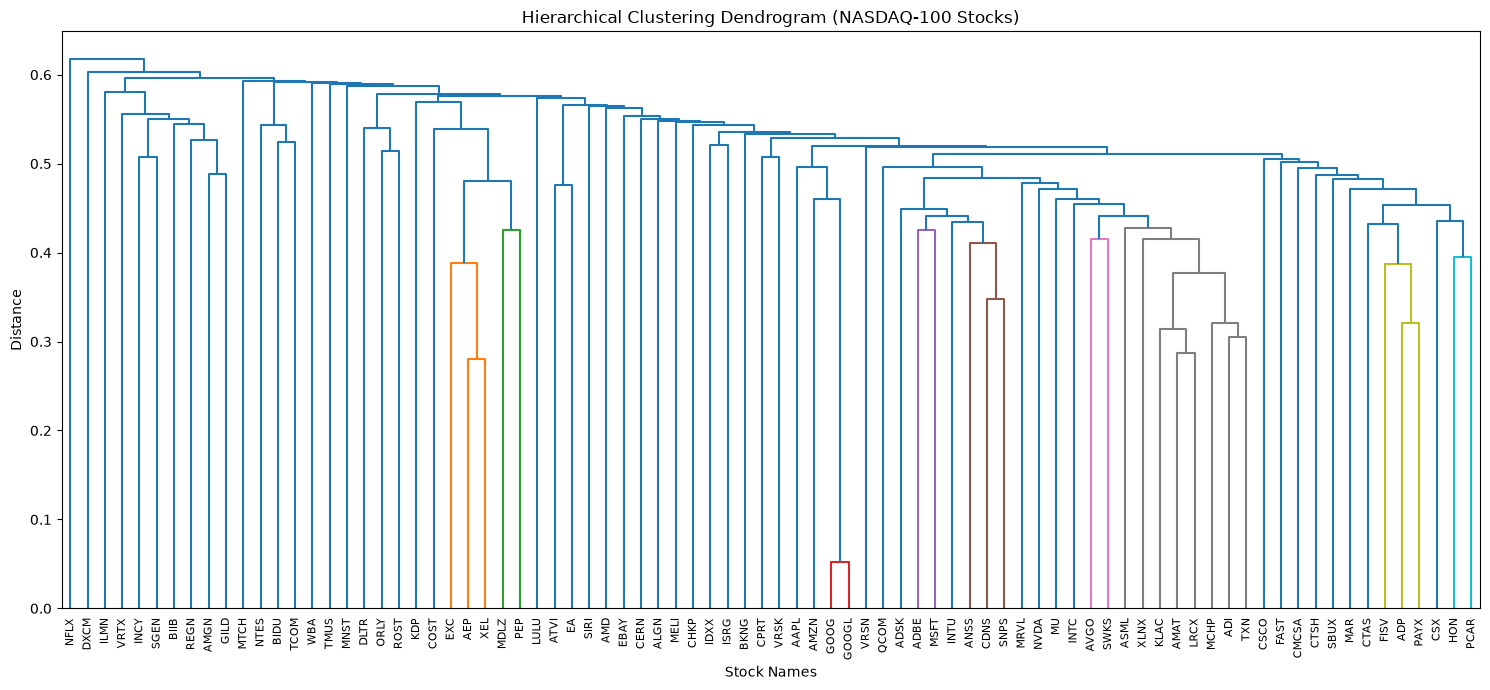

,Stock,Cluster
0,AAPL,1
1,ADBE,1
2,ADI,1
3,ADP,1
4,ADSK,1
...,...,...
77,VRSN,1
78,VRTX,1
79,WBA,1
29,DXCM,2


In [36]:
# step 1.1
corr_matrix = clean_returns.corr()

# step 1.2
dist_matrix = np.sqrt(0.5 * (1 - corr_matrix))
dist_vector = ssd.squareform(dist_matrix)

# step 1.3
Z = linkage(dist_vector, method='average') 

# step 2 
plt.figure(figsize=(15, 7))
plt.title("Hierarchical Clustering Dendrogram (NASDAQ-100 Stocks)")
plt.xlabel('Stock Names')
plt.ylabel('Distance')

dendrogram(
    Z, 
    labels=stock_names,
    leaf_rotation=90,
    leaf_font_size=8
)
plt.tight_layout()
plt.show()

# step 3 
max_clusters = 3
cluster = fcluster(Z, max_clusters, criterion='maxclust')

# step 4
df_clusters = pd.DataFrame({'Stock': stock_names, 'Cluster': cluster})
df_clusters.sort_values(by='Cluster')

## AgglomerativeClustering
### กราฟแบบ clean data ธรรมดา

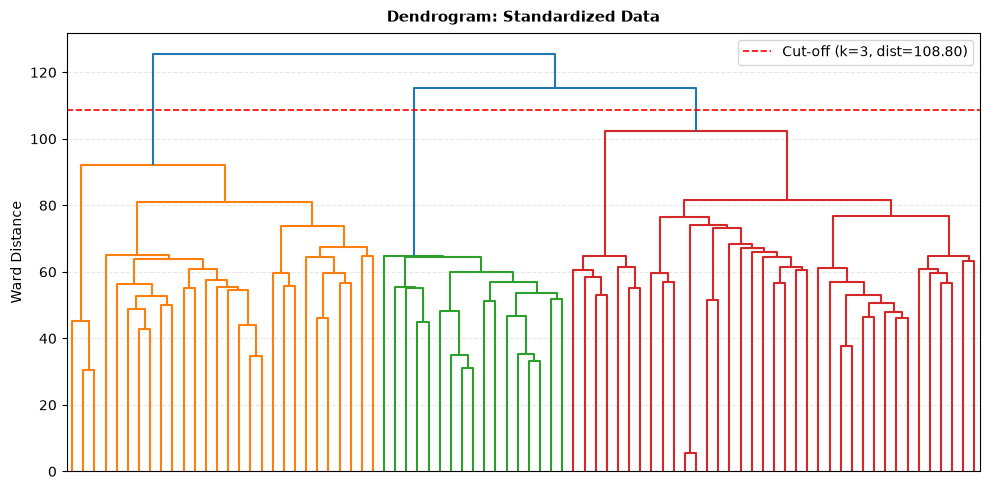

In [59]:
from sklearn.cluster import AgglomerativeClustering

agg_raw = AgglomerativeClustering(n_clusters=3, linkage='ward').fit(X)

fig, axes = plt.subplots(figsize=(10, 5))

Z = linkage(X, method="ward")
thresh = (Z[-2, 2] + Z[-3, 2]) / 2  # ระยะตัดแบ่ง k=3

ax1 = plt.gca()
dendrogram(Z, no_labels=True, color_threshold=thresh, ax=ax1)
ax1.axhline(
    
    thresh,
    color="red",
    linestyle="--",
    linewidth=1.2,
    label=f"Cut-off (k=3, dist={thresh:.2f})",
)
ax1.set_title("Dendrogram: Standardized Data", fontsize=11, fontweight="bold", pad=8)
ax1.set_ylabel("Ward Distance")
ax1.legend(loc="upper right")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### graph ที่ผ่านการทำ PCA

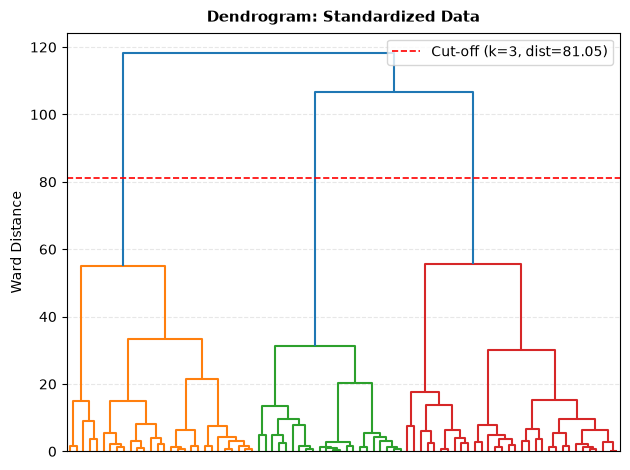

In [78]:
agg_pca = AgglomerativeClustering(n_clusters=3, linkage='ward').fit(pca_features)

# fig, axes = plt.subplots(figsize=(5, ))

Z = linkage(pca_features, method="ward")
thresh = (Z[-2, 2] + Z[-3, 2]) / 2  # ระยะตัดแบ่ง k=3

ax1 = plt.gca()
dendrogram(Z, no_labels=True, color_threshold=thresh, ax=ax1)
ax1.axhline(
    
    thresh,
    color="red",
    linestyle="--",
    linewidth=1.2,
    label=f"Cut-off (k=3, dist={thresh:.2f})",
)
ax1.set_title("Dendrogram: Standardized Data", fontsize=11, fontweight="bold", pad=8)
ax1.set_ylabel("Ward Distance")
ax1.legend(loc="upper right")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## การทำ Random Projection

In [71]:
from sklearn.random_projection import GaussianRandomProjection

In [74]:
grp = GaussianRandomProjection(n_components=80, random_state=42)
X_RP = grp.fit_transform(X)

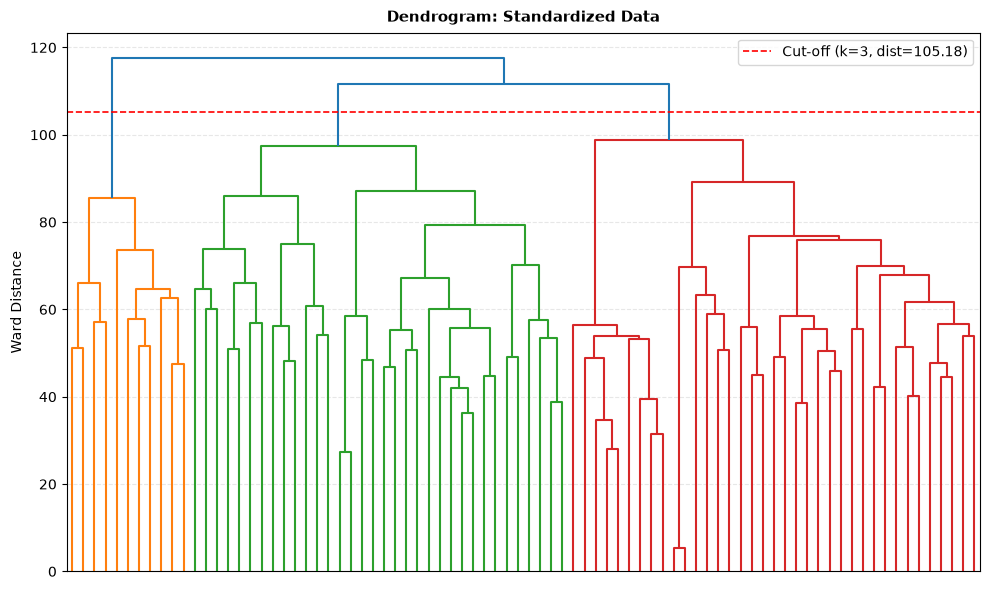

In [75]:
fig, axes = plt.subplots(figsize=(10, 6))

Z = linkage(X_RP, method="ward")
thresh = (Z[-2, 2] + Z[-3, 2]) / 2  # ระยะตัดแบ่ง k=3

ax1 = plt.gca()
dendrogram(Z, no_labels=True, color_threshold=thresh, ax=ax1)
ax1.axhline(
    
    thresh,
    color="red",
    linestyle="--",
    linewidth=1.2,
    label=f"Cut-off (k=3, dist={thresh:.2f})",
)
ax1.set_title("Dendrogram: Standardized Data", fontsize=11, fontweight="bold", pad=8)
ax1.set_ylabel("Ward Distance")
ax1.legend(loc="upper right")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()